# Competitive-scoring coalition analysis across years

Loops over one Pareto front per year (2000-2016). For every year it computes, for
each size-$m$ coalition:

* **coverage** — share of majority-win matchups whose win-set contains the coalition; and
* **win rate of its winning specialists** — every point is assigned to the coalition it
  *most wins through*; restricting to **winning points** (win rate $\ge 0.5$), we
  summarize the overall win rate of the winners assigned to each coalition by its
  **mean, median, 90th percentile, and max**. Only winners are included, so every value
  is $\ge 0.5$.

Reproduces the per-subject plots with **years** in place of subjects.

## 0. Configuration

In [1]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import glob, re
from itertools import combinations
from collections import Counter

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

FRONT_GLOB = 'pf_block_2_trial_*.csv'   # one front per year; year parsed from the filename
objectives = []                          # [] = take the columns from the files' header
CHUNK = 2000                             # rows per block in the pairwise scan
WIN_THRESHOLD = 0.5                      # a 'winning point' beats at least this share of the field
ACCENT = '#3B6EA5'

## 1. Discover the yearly front files

In [2]:
files = glob.glob(FRONT_GLOB)
year_files = sorted((int(re.search(r'_(\d{4})\.csv$', f).group(1)), f) for f in files)
years = [y for y, _ in year_files]
assert years, f"no files matched {FRONT_GLOB!r}"

if not objectives:
    objectives = list(pd.read_csv(year_files[0][1], nrows=0).columns)
for y, f in year_files:
    cols = list(pd.read_csv(f, nrows=0).columns)
    assert cols == objectives, f"{f} has {cols}, expected {objectives}"

D = len(objectives); m = D // 2 + 1
print(f"{len(year_files)} fronts, years {years[0]}-{years[-1]}")
print(f"objectives ({D}): {objectives}")
print(f"m = {m}   |   minimal coalitions = C({D},{m}) = {len(list(combinations(range(D), m)))}")

17 fronts, years 2000-2016
objectives (5): ['REB', 'AST', 'STL', 'BLK', 'PTS']
m = 3   |   minimal coalitions = C(5,3) = 10


## 2. Analyse one front

In [3]:
def analyze(X):
    N, D = X.shape
    m = D // 2 + 1
    majority_sizes = list(range(m, D))
    coals = list(combinations(range(D), m))
    masks = [sum(1 << d for d in c) for c in coals]
    weights = (1 << np.arange(D)).astype(np.int64)
    bmdt = np.int16 if D <= 15 else np.int64

    bit_counts = np.zeros(1 << D, dtype=np.int64); total = 0
    win_count  = np.zeros(N, dtype=np.int64)
    sweep      = np.zeros((len(coals), N), dtype=np.int64)
    for s in range(0, N, CHUNK):
        e = min(s + CHUNK, N); b = e - s
        wins_b = np.zeros((b, N), np.int16); bm = np.zeros((b, N), bmdt)
        for d in range(D):
            gd = X[s:e, d][:, None] > X[:, d][None, :]
            wins_b += gd; bm += gd * bmdt(weights[d])
        loc, glob = np.arange(b), np.arange(s, e)
        wins_b[loc, glob] = 0; bm[loc, glob] = 0
        maj = np.isin(wins_b, majority_sizes); maj[loc, glob] = False
        win_count[s:e] = maj.sum(1); total += int(maj.sum())
        bit_counts += np.bincount(bm[maj], minlength=1 << D)
        for ci, mask in enumerate(masks):
            sweep[ci, s:e] = ((bm & mask) == mask).sum(1)
        del wins_b, bm, maj

    cov = Counter()
    for W in np.flatnonzero(bit_counts):
        c = int(bit_counts[W]); members = [d for d in range(D) if (W >> d) & 1]
        for sub in combinations(members, m):
            cov[sub] += c
    coverage = {sub: (cov.get(sub, 0) / total if total else 0.0) for sub in coals}
    win_rate = win_count / (N - 1)
    return coals, coverage, sweep, win_rate

## 3. Run every year and build the summaries

In [4]:
cov_by_year, mean_by_year, med_by_year = {}, {}, {}
p90_by_year, max_by_year, cnt_by_year = {}, {}, {}
for yr, f in year_files:
    X = pd.read_csv(f)[objectives].to_numpy(dtype=float)
    coals, coverage, sweep, win_rate = analyze(X)
    dom = sweep.argmax(0)
    winner = win_rate >= WIN_THRESHOLD
    cov_by_year[yr] = {c: coverage[c] for c in coals}
    md_, mdd_, p9_, mx_, cd_ = {}, {}, {}, {}, {}
    for i, c in enumerate(coals):
        grp = win_rate[winner & (dom == i)]
        md_[c]  = float(grp.mean())             if grp.size else np.nan
        mdd_[c] = float(np.median(grp))         if grp.size else np.nan
        p9_[c]  = float(np.percentile(grp, 90)) if grp.size else np.nan
        mx_[c]  = float(grp.max())              if grp.size else np.nan
        cd_[c]  = int(grp.size)
    mean_by_year[yr], med_by_year[yr] = md_, mdd_
    p90_by_year[yr],  max_by_year[yr], cnt_by_year[yr] = p9_, mx_, cd_
    print(f"  {yr}: {X.shape[0]:>6,} points  |  winning points (>= {WIN_THRESHOLD:.0%}): {int(winner.sum()):,}")

def to_df(d):
    df = pd.DataFrame(d)
    df.index = ['+'.join(objectives[k] for k in sub) for sub in df.index]
    return df[sorted(df.columns)]

coverage_summary = to_df(cov_by_year)
meanwr_summary   = to_df(mean_by_year)
medianwr_summary = to_df(med_by_year)
p90wr_summary    = to_df(p90_by_year)
maxwr_summary    = to_df(max_by_year)
count_summary    = to_df(cnt_by_year)
meanwr_summary.round(3)

  2000: 11,266 points  |  winning points (>= 50%): 6,149


  2001:  9,367 points  |  winning points (>= 50%): 5,081


  2002: 12,189 points  |  winning points (>= 50%): 6,630


  2003:  8,126 points  |  winning points (>= 50%): 4,338


  2004: 11,264 points  |  winning points (>= 50%): 5,990


...

  2013:  7,973 points  |  winning points (>= 50%): 4,148


  2014:  5,811 points  |  winning points (>= 50%): 3,115


  2015:  5,924 points  |  winning points (>= 50%): 3,132


  2016:  6,004 points  |  winning points (>= 50%): 3,216


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
REB+AST+STL,0.564,0.560,0.563,0.552,0.534,0.520,0.531,0.538,0.568,0.539,0.540,0.560,0.559,0.529,0.558,NaN,0.557
REB+AST+BLK,0.546,0.557,0.543,0.524,0.528,0.544,0.539,0.528,0.559,0.527,0.528,0.510,NaN,NaN,0.513,0.545,0.553
REB+AST+PTS,0.559,NaN,0.548,NaN,NaN,NaN,NaN,NaN,0.540,0.521,NaN,0.539,NaN,NaN,0.579,0.549,NaN
REB+STL+BLK,0.578,0.595,0.592,0.610,0.615,0.596,0.610,0.616,0.583,0.579,0.600,0.639,0.624,0.622,0.586,0.559,0.574
REB+STL+PTS,0.638,0.614,0.598,0.661,0.555,0.595,0.609,0.652,0.567,0.613,0.644,0.674,0.663,0.669,0.642,0.597,0.622
REB+BLK+PTS,0.593,0.600,0.579,0.617,0.615,0.597,0.601,0.600,0.602,0.628,0.628,0.626,0.607,0.660,0.649,0.657,0.646
AST+STL+BLK,0.571,0.587,0.581,0.576,0.611,0.591,0.581,0.563,0.596,0.572,0.567,0.575,0.581,0.552,0.552,0.550,0.559
AST+STL+PTS,0.633,0.623,0.614,0.634,0.623,0.655,0.635,0.659,0.623,0.624,0.640,0.642,0.650,0.634,0.640,0.641,0.625
AST+BLK+PTS,0.577,0.567,0.543,NaN,0.591,0.577,0.572,0.564,0.601,0.589,0.563,0.538,0.554,0.534,0.566,0.640,0.593
STL+BLK+PTS,0.611,0.638,0.603,0.707,0.732,0.652,0.718,0.649,0.632,0.664,0.681,0.713,0.710,0.721,0.627,0.770,0.605


## 4. Plot helper

In [5]:
def year_lineplot(df, xlabel, title, xlim=None, vref=None):
    ypos = np.arange(len(df.index)); cmap = plt.get_cmap('tab20')
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    for k, yr in enumerate(df.columns):
        ax.plot(df[yr].values, ypos, marker='o', ms=5, lw=1.2, color=cmap(k % 20), label=str(yr))
    if vref is not None:
        ax.axvline(vref, color='0.5', ls='--', lw=1.2)
    ax.set_yticks(ypos); ax.set_yticklabels(df.index); ax.invert_yaxis()
    ax.set_xlim(*xlim) if xlim else ax.set_xlim(left=0)
    ax.set_xlabel(xlabel); ax.set_ylabel('Coalition'); ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout(); plt.show()

## 5. Coalition coverage by year

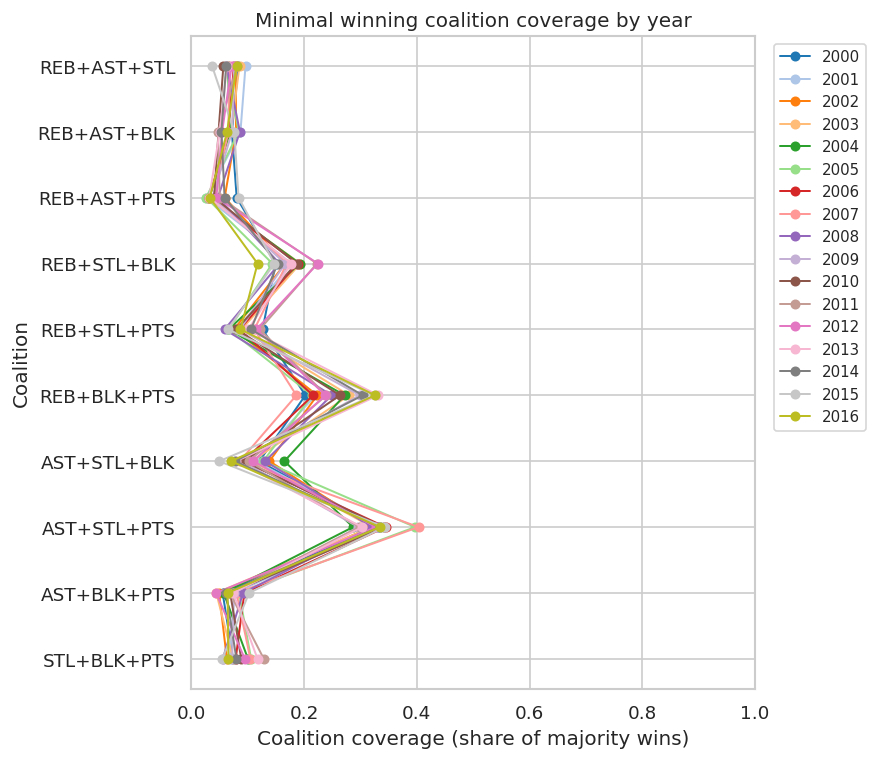

In [6]:
year_lineplot(coverage_summary, 'Coalition coverage (share of majority wins)',
              'Minimal winning coalition coverage by year', xlim=(0, 1.0))

## 6. Mean win rate of winning specialists, by coalition

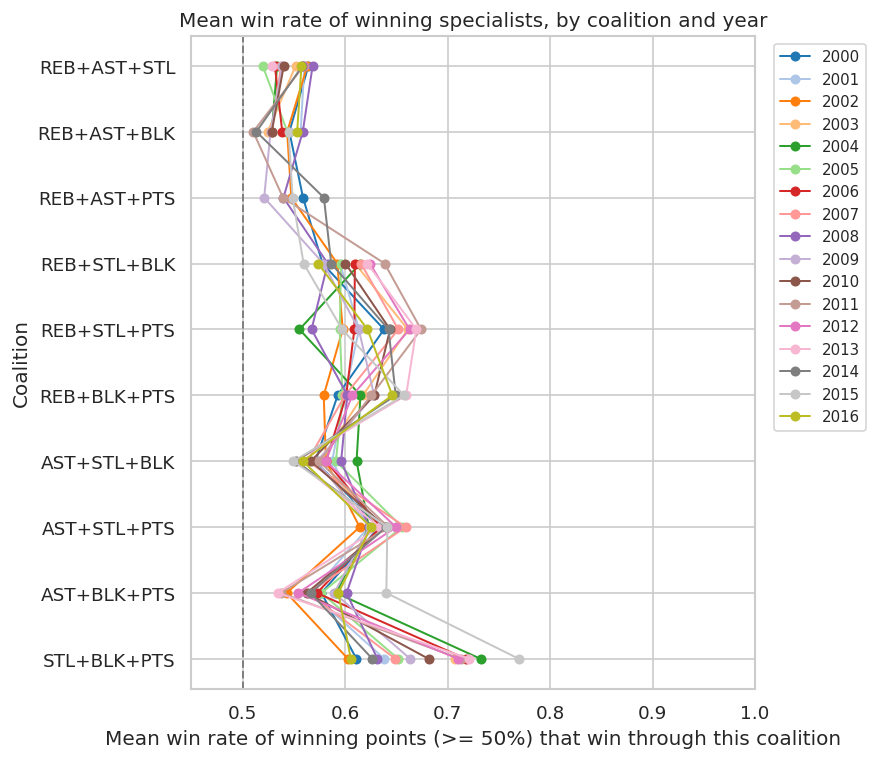

In [7]:
year_lineplot(meanwr_summary, 'Mean win rate of winning points (>= 50%) that win through this coalition',
              'Mean win rate of winning specialists, by coalition and year', xlim=(0.45, 1.0), vref=0.5)

## 7. Median win rate of winning specialists, by coalition

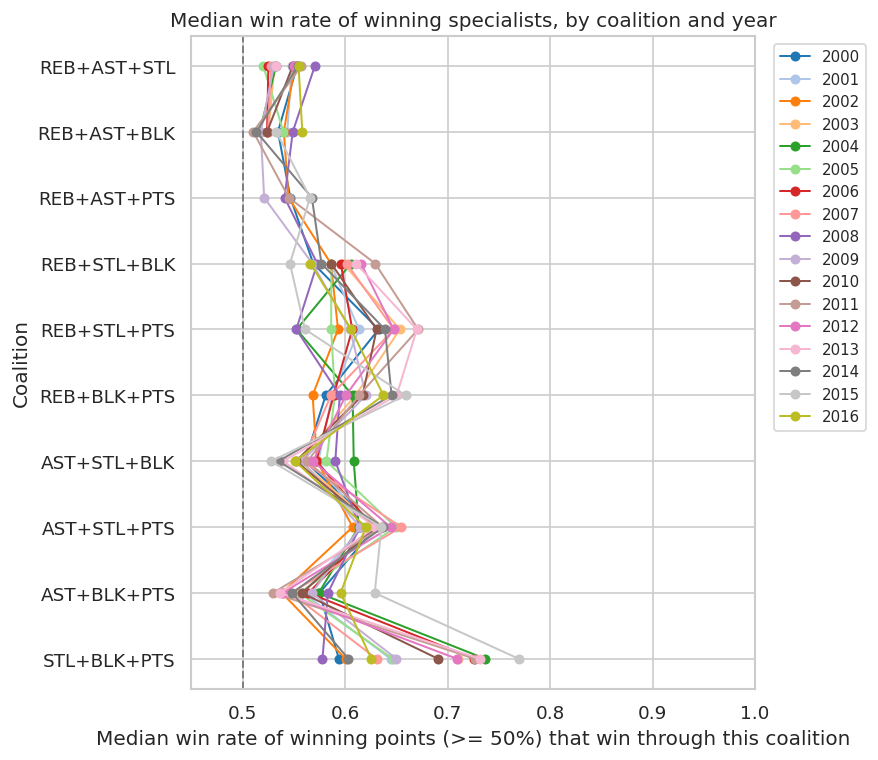

In [8]:
year_lineplot(medianwr_summary, 'Median win rate of winning points (>= 50%) that win through this coalition',
              'Median win rate of winning specialists, by coalition and year', xlim=(0.45, 1.0), vref=0.5)

## 8. 90th-percentile win rate, by coalition

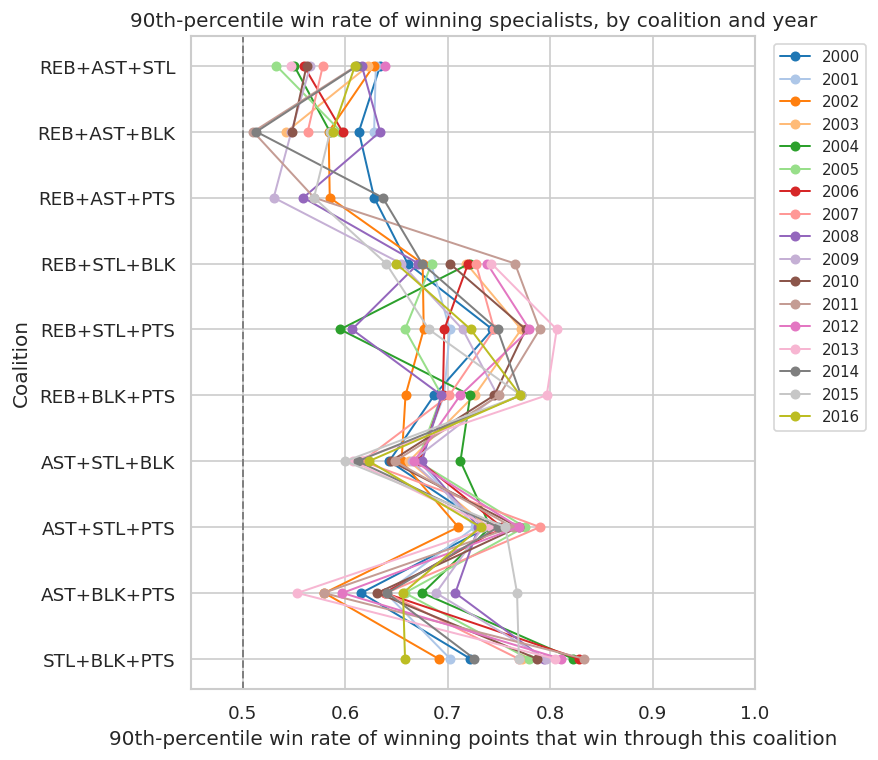

In [9]:
year_lineplot(p90wr_summary, '90th-percentile win rate of winning points that win through this coalition',
              '90th-percentile win rate of winning specialists, by coalition and year', xlim=(0.45, 1.0), vref=0.5)

## 9. Max win rate, by coalition

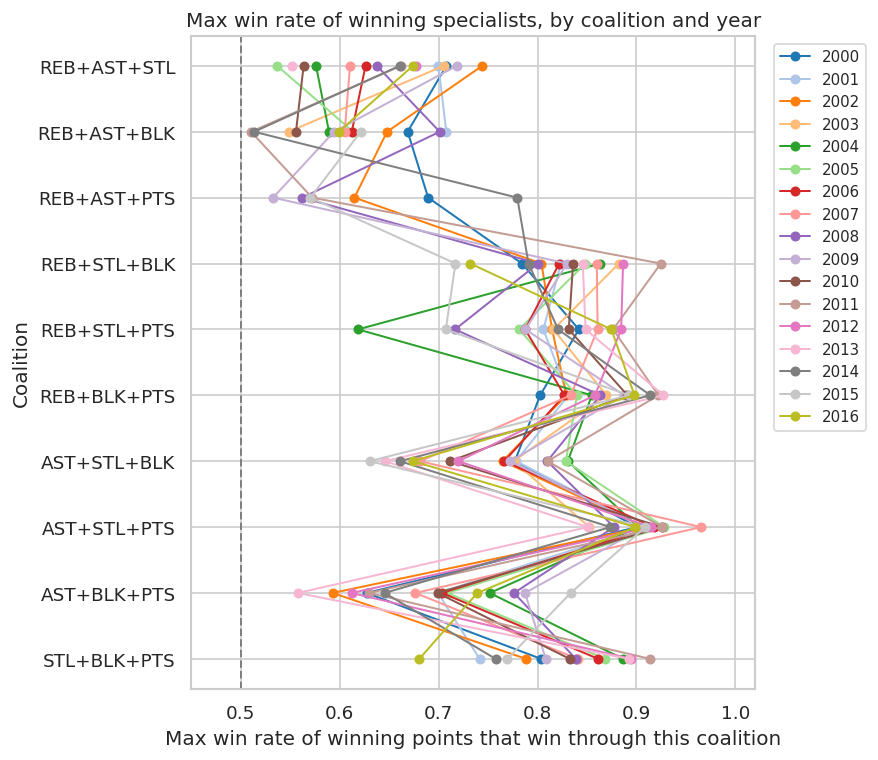

In [10]:
year_lineplot(maxwr_summary, 'Max win rate of winning points that win through this coalition',
              'Max win rate of winning specialists, by coalition and year', xlim=(0.45, 1.02), vref=0.5)

## 10. Combined: median / 90th / max, with across-year variability

The three upper-distribution statistics on one axis. Each point is the **mean across
years**; the horizontal bar is **$\pm 1$ SD across years**, so a wide bar means the
coalition's specialists varied a lot from season to season.

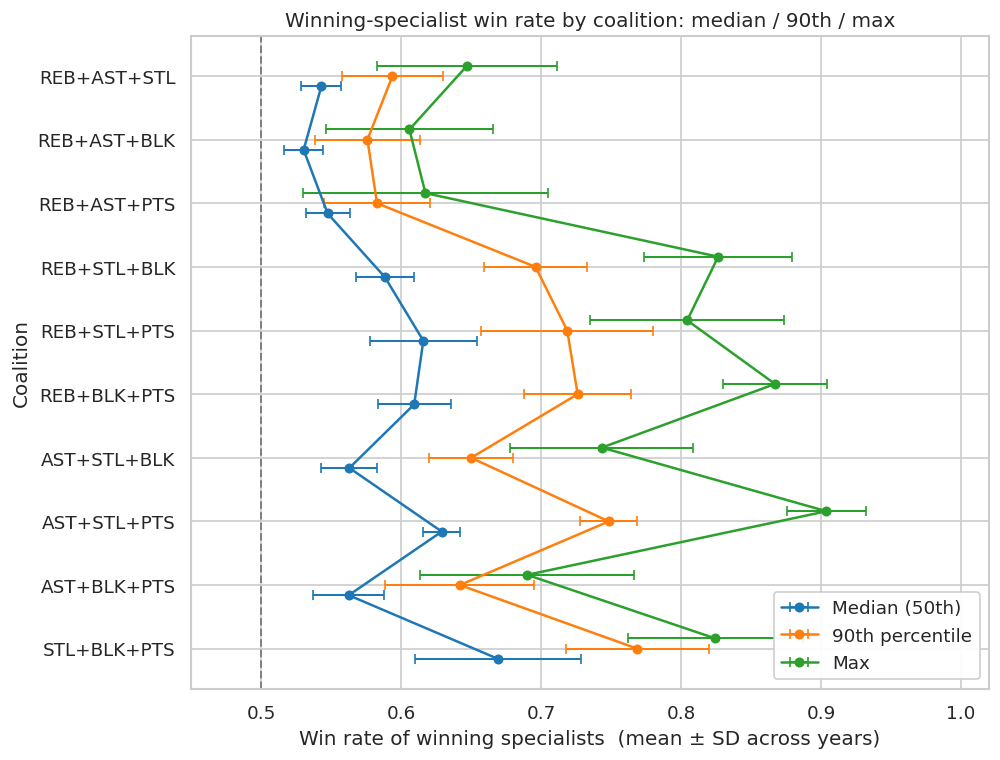

In [11]:
stats = [('Median (50th)', medianwr_summary, '#1f77b4'),
         ('90th percentile', p90wr_summary,    '#ff7f0e'),
         ('Max',             maxwr_summary,     '#2ca02c')]
labels = coverage_summary.index; ypos = np.arange(len(labels))
offsets = [0.16, 0.0, -0.16]
fig, ax = plt.subplots(figsize=(8.5, 6.5))
for (name, df, color), off in zip(stats, offsets):
    ax.errorbar(df.mean(axis=1).values, ypos + off, xerr=df.std(axis=1).values,
                fmt='o-', color=color, label=name, capsize=3, lw=1.5, ms=5, elinewidth=1.2)
ax.axvline(0.5, color='0.5', ls='--', lw=1.2)
ax.set_yticks(ypos); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlim(0.45, 1.02)
ax.set_xlabel('Win rate of winning specialists  (mean \u00b1 SD across years)')
ax.set_ylabel('Coalition')
ax.set_title('Winning-specialist win rate by coalition: median / 90th / max')
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout(); plt.show()

Overall figure

## 11. Export

In [12]:
coverage_summary.to_csv('coalition_coverage_by_year.csv')
meanwr_summary.to_csv('coalition_mean_winrate_by_year.csv')
medianwr_summary.to_csv('coalition_median_winrate_by_year.csv')
p90wr_summary.to_csv('coalition_p90_winrate_by_year.csv')
maxwr_summary.to_csv('coalition_max_winrate_by_year.csv')
count_summary.to_csv('coalition_winner_counts_by_year.csv')
print('wrote coverage, mean/median/p90/max win-rate, and winner-count summaries')

wrote coverage, mean/median/p90/max win-rate, and winner-count summaries
